In [5]:
%load_ext autoreload
%autoreload 2
import os,sys
import torch
import numpy as np
import pandas as pd 

os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
from PINN import models
import matplotlib.pyplot as plt

In [6]:
from PINN import models

# define the velocity and then simuate the coordinates

Suppose we have n dimensional initital cells. Each coordinate is independent of each other

In [4]:
n_knot = 5
n_smooth = 1
n_dimension = 5

def generate_positive_knot(n_knot, n_smooth = 1):
    """
    randomly return `n` knots with the minimum value placed as the first one
    """
    # max_height = np.random.randint(0,50)/100
    base = np.random.randint(low=0, high=30, size=(n_knot+n_smooth,))/100 + np.random.random((n_knot+n_smooth,))/10

    # smoothed the 
    for i in range(n_smooth):
        base = (base[:-1]+base[1:]) / 2 
    
    vmin = np.min(base)
    rest = [v for v in base if v!= vmin]
    knots = [vmin] + rest
    return np.array(knots)

def generate_v_knots(n_dimension, n_knot, n_smooth = 1):
    """
    generate n dimensional knot groups
    """
    all_knots = []
    for d in range(n_dimension):

        positive_base = generate_positive_knot(n_knot, n_smooth)

        negative_base = -1 * generate_positive_knot(n_knot, n_smooth)[::-1]

        v_knots_i = [0] + list(negative_base) + list(positive_base) + [0]

        all_knots.append(v_knots_i)
    y_knots = np.stack(all_knots)

    X_knots = []
    for d in range(n_dimension):
        DM_max = np.random.randint(30,80)/10
        X_knots.append(torch.linspace(-1*DM_max, DM_max, 12).float())

    return torch.stack(X_knots), torch.from_numpy(y_knots)

In [5]:
def generate_g_knots(n_dimension, n_knot, high=200):
    """
    generate n dimensional knot groups
    """
    all_knots = []
    for d in range(n_dimension):

        base = np.random.randint(low=0, high=high, size=(n_knot,))/100
        
        all_knots.append(base)
    y_knots = np.stack(all_knots)

    return torch.from_numpy(y_knots).float()

def generate_D_knots(n_dimension, n_knot, high=10):
    """
    generate n dimensional knot groups
    """
    all_knots = []
    for d in range(n_dimension):

        base = np.random.randint(low=-10, high=high, size=(n_knot,))/100
        
        all_knots.append(base)
    y_knots = np.stack(all_knots)

    return torch.from_numpy(y_knots).float()

In [79]:
x_knots, v_knots = generate_v_knots(5, 5, 0)

In [83]:
for n in range(n_dimension):
    
    if np.random.random() < 0.5:
        # for negative 
        loc = np.random.randint(1,5)
        v_knots[n, loc] = 0.1 * v_knots[n, loc]
        v_knots[n, loc+1] = 3 * v_knots[n, loc+1]
        print(n,loc)

    if np.random.random() < 0.5:
        # for negative 
        loc = np.random.randint(6,10)
        v_knots[n, loc] = 3 * v_knots[n, loc]
        v_knots[n, loc+1] = 0.1 * v_knots[n, loc+1]
        print(n,loc)
v_knots

0 2
1 2
2 1
2 9
3 3
4 7


tensor([[ 0.0000, -0.0295, -0.0463, -0.4227, -0.2666, -0.1328,  0.1275,  0.2491,
          0.1413,  0.3573,  0.1306,  0.0000],
        [ 0.0000, -0.2285, -0.0332, -0.1036, -0.0963, -0.4933,  0.0520,  0.2846,
          0.2213,  0.0822,  0.2227,  0.0000],
        [ 0.0000, -0.0375, -0.0934, -0.0602, -0.0533, -0.2953,  0.1222,  0.6788,
          0.0701,  0.1018,  0.0161,  0.0000],
        [ 0.0000, -0.2361, -0.2036, -0.0196, -0.0630, -0.3523,  0.0656,  0.4595,
          0.0259,  0.2263,  0.0770,  0.0000],
        [ 0.0000, -0.0318, -0.0284, -0.5644, -0.2281, -0.0872,  0.0193,  3.1312,
          0.0071,  0.0209,  0.1838,  0.0000]], dtype=torch.float64)

In [178]:
g_knots = generate_g_knots(5,12, high=50)


if np.random.random() < 0.5: # for negative 
    loc = np.random.randint(0,5)
    g_knots[:,loc] = g_knots[:,loc] * 3

if np.random.random() < 0.5: # for negative 
    loc = np.random.randint(6,11)
    g_knots[:,loc] = g_knots[:,loc] * 3

In [179]:
g_knots

tensor([[0.1900, 0.3300, 1.1700, 0.0000, 0.4400, 0.3800, 0.3500, 0.1300, 0.4000,
         0.1500, 1.4700, 0.0300],
        [0.3100, 0.0500, 1.4100, 0.3200, 0.4300, 0.3800, 0.2200, 0.2800, 0.1400,
         0.2200, 0.3900, 0.2000],
        [0.2600, 0.4000, 1.4700, 0.4900, 0.3800, 0.2900, 0.3300, 0.3300, 0.4400,
         0.1100, 0.7200, 0.1600],
        [0.2000, 0.1900, 0.4200, 0.0700, 0.0700, 0.0500, 0.3100, 0.0700, 0.0400,
         0.2200, 1.2600, 0.3400],
        [0.3900, 0.2700, 1.3800, 0.3900, 0.0600, 0.4600, 0.0800, 0.3600, 0.3200,
         0.0600, 0.9900, 0.2600]])

In [206]:
D_knots = generate_D_knots(5,12)
g_cs = models.MultiDim_CubicSpline(y=g_knots.T, x=x_knots.T, collapse=True)
D_cs = models.MultiDim_CubicSpline(y=D_knots.T, x=x_knots.T, collapse=True)

/ssd/users/Wergillius/Project/PINN_dynamics/PINN/models/Spline_models.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer("x", torch.tensor(x, dtype=torch.float32, requires_grad=False))


In [87]:
m_cs = models.MultiDim_CubicSpline(y=v_knots.T, x=x_knots.T)

In [293]:
param_ckpt = {
    'x' : x_knots,
    'g' : g_knots,
    'v' : v_knots,
    'D' : D_knots,
}

torch.save(param_ckpt, "data/synthesized_data/5Dim_ncs_synparam_Jan21/ncs_param_Jan21.ckpt")

# simulate random cells

In [250]:
starting_cells = []
starting_cells.append(torch.randn(100, 5).float() / 4)
starting_cells.append(torch.randn(50, 5).float() / 16 + torch.randn((1,5)) / 4) 
starting_cells.append(torch.randn(50, 5).float() / 16 + torch.randn((1,5)) / 8) 
starting_cells.append(torch.randn(50, 5).float() / 8 + torch.randn((1,5)) / 4) 

starting_cells = torch.cat(starting_cells, dim=0).float()

velocity

In [7]:
spline_knots = torch.load("data/synthesized_data/5Dim_ncs_synparam_Jan21/ncs_param_Jan21.ckpt")

v_spline = models.MultiDim_CubicSpline(y=spline_knots['v'].T, x=spline_knots['x'].T)
g_spline = models.MultiDim_CubicSpline(y=spline_knots['g'].T, x=spline_knots['x'].T, collapse=True)
D_spline = models.MultiDim_CubicSpline(y=spline_knots['D'].T, x=spline_knots['x'].T, collapse=True)

/ssd/users/Wergillius/Project/PINN_dynamics/PINN/models/Spline_models.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer("x", torch.tensor(x, dtype=torch.float32, requires_grad=False))


In [9]:
syn_init_ckpt = torch.load("data/synthesized_data/5Dim_ncs_synparam_Jan21/syn_init_condition.ckpt")
cellstate = syn_init_ckpt['cellstate']
starting_cells = cellstate[:250]

In [41]:
alldata = cellstate.numpy()

In [10]:
from torchdiffeq import odeint

Text(0.5, 0, 'time')

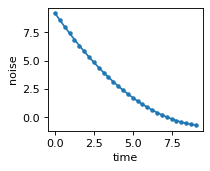

In [13]:
t = np.linspace(0,9,30)
D = (10-t)**2 /10 - 0.8

fig, axs = plt.subplots(1,1, figsize=(2.5,2), dpi=80)
plt.plot(t, D, marker='.')
plt.ylabel("noise")
plt.xlabel("time")

In [16]:
device = 'cuda:5'

In [17]:
m_cs = v_spline.to(device)
def odefun(t, cs):
    return m_cs(cs)


def sdefun(t, cs):
    v = m_cs(cs)
    D = (10-t)**0.5 - 0.8
    noise = torch.randn_like(v) * D
    return v+ noise

In [ ]:
integrat_time = torch.linspace(0, 4, 11).float()

with torch.no_grad():
    trajectory = odeint(odefun, 
                    y0=starting_cells.clone().to(device), 
                    t=integrat_time, 
                    atol=1e-4, rtol=1e-4)


# try simulate celll with noise
with torch.no_grad():
    trajectory_noised = odeint(sdefun, 
                    y0=starting_cells.clone().to(device), 
                    t=integrat_time, 
                    atol=1e-4, rtol=1e-4)

starting_coords = starting_cells.numpy()
trajectory = trajectory.cpu().numpy()
trajectory_noised = trajectory_noised.cpu().numpy()

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:306: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")
/ssd/users/Wergillius/Project/PINN_dynamics/PINN/models/Spline_models.py:71: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at ../aten/src/ATen/native/BucketizationUtils.h:32.)
  idxs = torch.searchsorted(self.x[1:], xs)


In [108]:
def plot_timepoints(trajectory, trajectory_noised, timepoint_index, dim=[0,1]):

    n_time = len(timepoint_index)

    fig, axs = plt.subplots(1, n_time, figsize=(2.3*n_time,2), dpi=100, sharex=True, sharey=True)
    for i, t in enumerate(timepoint_index):
        axs[i].scatter(trajectory[0, :,dim[0]], trajectory[0, :,dim[1]], color='grey', alpha=0.3, s=8)
        axs[i].scatter(trajectory[t,:,dim[0]], trajectory[t,:,dim[1]], color='#383D67', alpha=0.8, s=8)
        axs[-1].legend(['starting cell', 'simulated by ode'], ncols=2, bbox_to_anchor=(-0.5,1.2,0.3,0.05))

    fig2, axs2 = plt.subplots(1, n_time, figsize=(2.3*n_time,2), dpi=100, sharex=True, sharey=True)
    for i, t in enumerate(timepoint_index):
        axs2[i].scatter(trajectory_noised[0, :,dim[0]], trajectory_noised[0, :,dim[1]], color='grey', alpha=0.3, s=8)
        axs2[i].scatter(trajectory_noised[t,:,dim[0]], trajectory_noised[t,:,dim[1]], color='#E39B8C', alpha=0.8, s=8)
        axs2[-1].legend(['starting cell', 'simulated by sde'], ncols=2, bbox_to_anchor=(-0.5,1.2,0.3,0.05))

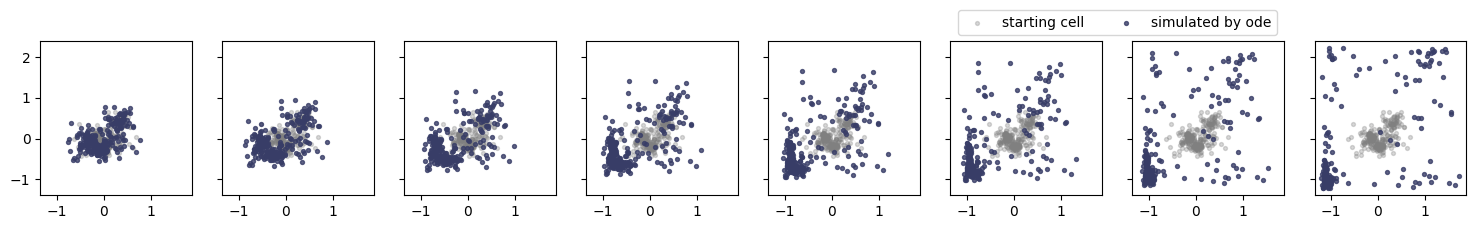

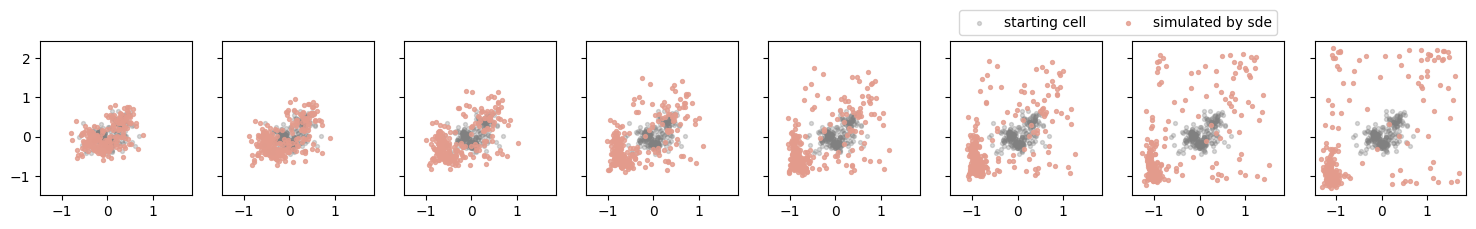

In [255]:
plot_timepoints(trajectory, trajectory_noised, [1,2,3,4,5,6, 8, 10], dim=[1,2])

In [256]:
integrat_time[[1,2,3,4,5,6]]

tensor([0.4000, 0.8000, 1.2000, 1.6000, 2.0000, 2.4000])

In [27]:
all_data_bytime = trajectory_noised[[1,2,3,4,5,6]]
all_data = all_data_bytime.reshape(-1,n_dimension)

all_ds = ds[np.arange(6)].reshape(-1,5)
all_ds.shape

(1500, 5)

In [22]:
ds = np.diff(trajectory_noised, axis=0)

In [23]:
ds.shape

(9, 250, 5)

In [259]:
all_data.T.shape

(5, 1500)

In [267]:
import umap
import phate

from scipy.stats import gaussian_kde

In [270]:
kde_fn_init = gaussian_kde(all_data_bytime[0].T, bw_method=1.5)
u_all = kde_fn_init(all_data.T)
kde_fn_last = gaussian_kde(all_data_bytime[-1].T, bw_method=1.5)
u_all_last = kde_fn_last(all_data.T)

In [268]:
ump_transfor = umap.UMAP(n_neighbors=15)
X_umap = ump_transfor.fit_transform(all_data)

phate_op = phate.PHATE()
X_phate = phate_op.fit_transform(all_data)

Calculating PHATE...
  Running PHATE on 1500 observations and 5 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.03 seconds.
    Calculating affinities...
  Calculated graph and diffusion operator in 0.04 seconds.
  Calculating optimal t...
    Automatically selected t = 27
  Calculated optimal t in 0.64 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.17 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 2.21 seconds.
Calculated PHATE in 3.07 seconds.


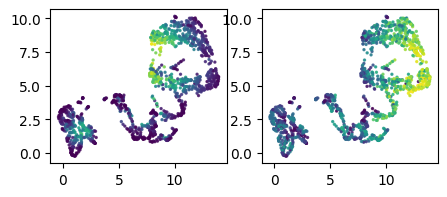

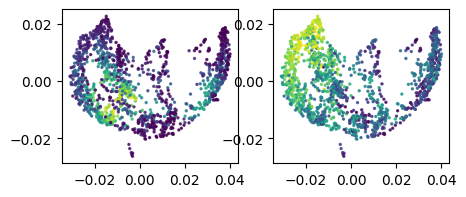

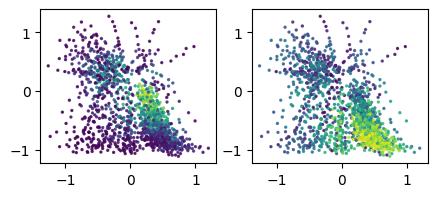

In [271]:
fig, axs = plt.subplots(1,2, figsize=(5,2), dpi=100)
axs[0].scatter(X_umap[:,0], X_umap[:,1], c=u_all, s=2, alpha=0.8)
axs[1].scatter(X_umap[:,0], X_umap[:,1], c=u_all_last, s=2, alpha=0.8)

fig, axs = plt.subplots(1,2, figsize=(5,2), dpi=100)
axs[0].scatter(X_phate[:,0], X_phate[:,1], c=u_all, s=2, alpha=0.8)
axs[1].scatter(X_phate[:,0], X_phate[:,1], c=u_all_last, s=2, alpha=0.8)

fig, ax = plt.subplots(1,2, figsize=(5,2), dpi=100)
ax[0].scatter(all_data[:,0], all_data[:,1], c=u_all, s=2, alpha=0.8)
ax[1].scatter(all_data[:,0], all_data[:,1], c=u_all_last, s=2, alpha=0.8)

# init duds

In [32]:
from torch import nn
from torchdiffeq import odeint

[autoreload of PINN.models._pde_informed_params failed: Traceback (most recent call last):
  File "/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 475, in superreload
    module = reload(module)
  File "/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 613, in _exec
  File "<frozen importlib._bootstrap_external>", line 846, in exec_module
  File "<frozen importlib._bootstrap_external>", line 983, in get_code
  File "<frozen importlib._bootstrap_external>", line 913, in source_to_code
  File "<frozen importlib._bootstrap>", line 228, in _call_with_frames_removed
  File "/ssd/users/Wergillius/Project/PINN

In [33]:
torch.nn.functional.relu

<function torch.nn.functional.relu(input: torch.Tensor, inplace: bool = False) -> torch.Tensor>

In [34]:
class Syn_model(nn.Module):

    def __init__(self, g_model, v_model, D_model):
        super().__init__()
        self.g = g_model
        self.v = v_model
        self.D = D_model
        self.relu = nn.ReLU()
    
    def gradient_of(self, out, variable):
        return torch.autograd.grad(out, variable, create_graph=True, allow_unused=True)[0] 

    
    def forward(self, t, states):
        """
        the ODE function used for odeint
        """
        u = self.relu(states[0])
        s = states[1]
        duds = states[2]
        device = s.device

        with torch.set_grad_enabled(True):
            
            u = u.requires_grad_(True).float()
            s = s.requires_grad_(True).float()
            duds = duds.requires_grad_(True).float()

            # u = torch.exp(self.u(s, t_in)) # make sure it is u but not log u

            D = self.D(s,None)
            v = self.v(s,None)
            g = self.g(s,None).flatten()
            
            # the first order deviritives of density u to time : ∂u/∂s

            duds_backward = self.gradient_of(u.sum(), s)
            if duds_backward is None:
                # print(t)
                duds = duds.requires_grad_(True)
            else:
                duds = duds_backward
            
            
            # the first term:  a second order derivative
            Du = torch.mul(D, duds)   # element-wise 
            d2Dds2 = self.gradient_of(Du.sum(), s)  
            
            # the second term : ∂/∂s[ v*u ]
            dvds_ls  = []
            for i in range(v.shape[1]):
                du_dsisi = self.gradient_of(v[:,i].sum(), s)[:, i:i+1]
                dvds_ls.append(du_dsisi)
            dvds = torch.cat(dvds_ls, dim=1)
            # print(dvds.shape)
            # print(u.shape)
            dvuds = dvds * u.reshape(-1,1) + torch.mul(duds, v)
            
            # right hand side
            diffuse = d2Dds2.sum(dim=1)
            drift = dvuds.sum(dim=1)
            growth = torch.mul(g, u)

            dudt = growth - drift + diffuse

            # set ds to zeros to fix cellstates
            dsdt = torch.zeros_like(s).float().to(device).requires_grad_(True)

            # duds_by_time = dsdt  
            duds_by_time = self.gradient_of(dudt.sum(), s)

            

        return dudt, dsdt, duds_by_time, growth , drift , diffuse

# simulate

In [35]:
device='cuda:6'

In [36]:
model = Syn_model(g_cs, m_cs, D_cs).to(device)

NameError: name 'g_cs' is not defined

In [42]:
dm_range = all_data.max(axis=0) - all_data.min(axis=0)
ds = dm_range / 1000

du_dcs_t = []
for dim in range(n_dimension):
    dcs = np.zeros_like(all_data)
    dcs[:,dim] = np.full((dcs.shape[0],), ds[dim])
    s_prime = all_data + dcs

    dudcs_dim = (kde_fn_init(s_prime.T) - kde_fn_init(all_data.T)) / ds[dim]
    du_dcs_t.append(dudcs_dim)
du_dcs_t = torch.from_numpy(np.stack(du_dcs_t).T)

du_dcs_t = du_dcs_t.float().to(device)
u_init = torch.from_numpy(u_all).float().to(device)
cellstate = torch.from_numpy(all_data).float().to(device)

zeros = torch.zeros_like(u_init)
init = (u_init, cellstate, du_dcs_t, zeros, zeros, zeros)

NameError: name 'all_data' is not defined

In [281]:
sim_out = odeint(
    model, init, t=torch.linspace(0, 2, 11).float(),
    rtol=1e-4, atol=1e-5,    
)

torch.cuda.empty_cache()

u_sim = model.relu(sim_out[0]).detach().cpu().numpy()
u_sim.sum(axis=1)

array([ 271.38657,  358.0357 ,  458.6557 ,  580.61676,  736.7925 ,
        949.0766 , 1258.8198 , 1731.7847 , 2462.798  , 3604.9185 ,
       5403.392  ], dtype=float32)

In [282]:
growth = sim_out[3].detach().cpu().numpy()

In [283]:
drift = sim_out[4].detach().cpu().numpy()

In [284]:
growth[1, :100]

array([0.10763872, 0.06199969, 0.05264059, 0.05937987, 0.07951763,
       0.10110506, 0.08458208, 0.0699686 , 0.01706353, 0.13279921,
       0.08516847, 0.07525631, 0.14553833, 0.07390106, 0.13349862,
       0.0299409 , 0.11006577, 0.00609768, 0.12101468, 0.02701074,
       0.03044578, 0.0841224 , 0.01544976, 0.09913404, 0.0484685 ,
       0.06149124, 0.08338663, 0.08472371, 0.1077107 , 0.0524769 ,
       0.04316463, 0.11457263, 0.02308743, 0.10918807, 0.15263696,
       0.02593376, 0.04105719, 0.10393421, 0.08813408, 0.06474508,
       0.03548637, 0.05918676, 0.07709115, 0.11782066, 0.05050977,
       0.05226712, 0.03535884, 0.0537471 , 0.09406672, 0.0327795 ,
       0.10509884, 0.04432229, 0.07491203, 0.0319404 , 0.07353496,
       0.04209477, 0.14873238, 0.08752134, 0.04381676, 0.08695927,
       0.07843392, 0.11195221, 0.07609382, 0.04705701, 0.00679542,
       0.01885504, 0.01973403, 0.02662443, 0.15740621, 0.05345465,
       0.12162488, 0.1785595 , 0.08926237, 0.01008877, 0.04023

In [285]:
drift[1, :100]

array([-0.06513276, -0.01071177,  0.00547819,  0.02664532,  0.07420709,
       -0.04743612,  0.06460007,  0.00656081,  0.04048702,  0.1531626 ,
        0.07329626,  0.06467365,  0.11967105,  0.04879711, -0.01694585,
        0.00537846,  0.09453852, -0.00075284,  0.07320418,  0.0150082 ,
       -0.00410084,  0.069263  , -0.00694794,  0.18850902, -0.01138653,
        0.10878348,  0.07223336,  0.03298959, -0.00255278,  0.02394412,
       -0.02448392, -0.00102012,  0.02406349,  0.1292607 ,  0.19295302,
        0.00361477,  0.03939183,  0.17256722,  0.03606535,  0.02440437,
        0.01074134, -0.00973946,  0.17239203,  0.05669003,  0.01042274,
        0.07039633,  0.02516318,  0.06296048,  0.0910879 ,  0.00402384,
        0.15619297,  0.04413334,  0.0418913 , -0.0148466 , -0.05341775,
        0.05046453, -0.06095323, -0.01572257, -0.03126835,  0.07405281,
        0.14322318,  0.04784666,  0.11334492, -0.02273759, -0.00301984,
        0.00507038, -0.00257669,  0.0030399 , -0.003061  ,  0.00

In [286]:
u_sim[u_sim!=0].min()

4.548547e-08

In [313]:
integrat_time = np.linspace(0, 2, 11)

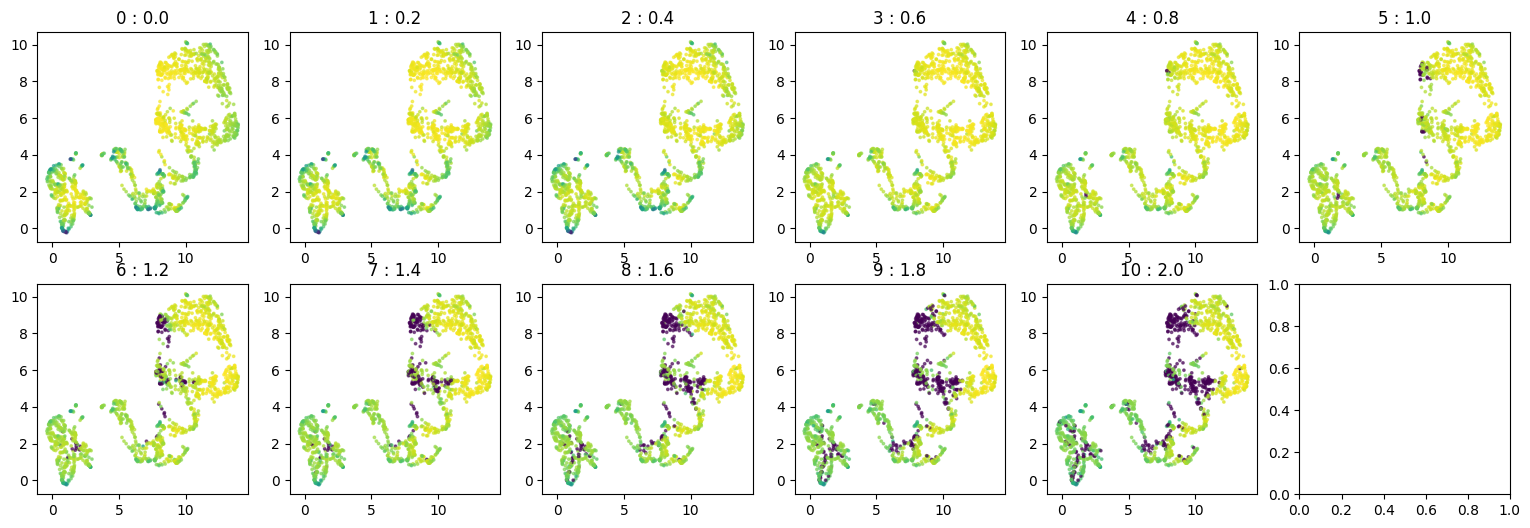

In [314]:
fig, axs = plt.subplots(2, 6, figsize=(19,6), dpi=100)
axs = axs.flatten()

for i, u in enumerate(u_sim):
    axs[i].scatter(X_umap[:,0], X_umap[:,1], c=np.log(u_sim[i]+1e-10), s=3, alpha=0.6)
    axs[i].set_title(f"{i} : {np.round(integrat_time[i],decimals=3)}")

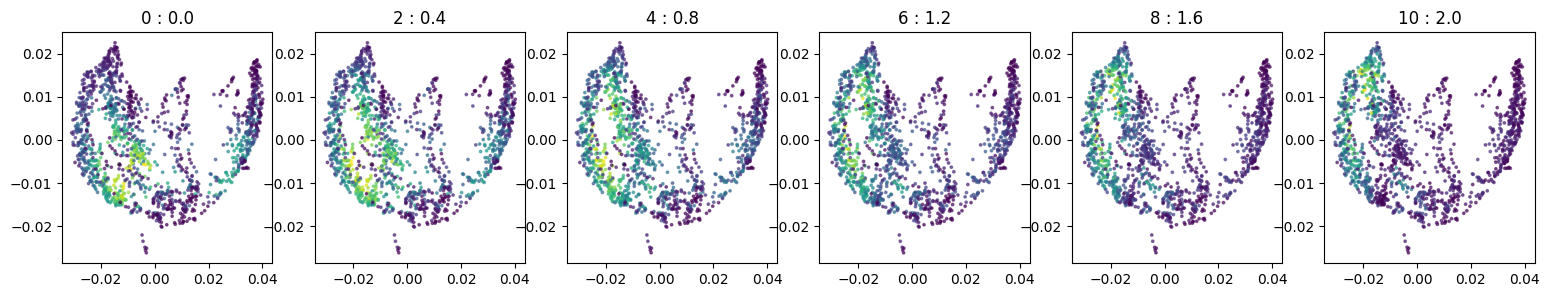

In [315]:
fig, axs = plt.subplots(1, 6, figsize=(19,3), dpi=100)
axs = axs.flatten()

for i, u in enumerate(u_sim[::2]):
    axs[i].scatter(X_phate[:,0], X_phate[:,1], c=u_sim[i]+1e-10, s=3, alpha=0.6)
    axs[i].set_title(f"{i*2} : {np.round(integrat_time[i*2],3)}")

In [298]:
synthesize_condition = {  "u_init": u_init.cpu(), 
    "cellstate":cellstate.cpu(), 
    "duds" : du_dcs_t.cpu(),
    "integrate_time": torch.linspace(0, 2, 11).float()
}
torch.save(synthesize_condition, "data/synthesized_data/5Dim_ncs_synparam_Jan21/syn_init_condition.ckpt")

In [302]:
simulate_result = {
    "u_simulate" : torch.from_numpy(u_sim).float(),
    "integrate_time": torch.linspace(0, 2, 11).float(),
    "delta_x" : torch.from_numpy(all_ds).float()
}
torch.save(simulate_result, "data/synthesized_data/5Dim_ncs_synparam_Jan21/syn_result.ckpt")

In [316]:
u_sim.max()

42.004677

# reload synthesized data
convert to adata

In [2]:
syn_init_ckpt = torch.load("data/synthesized_data/5Dim_ncs_synparam_Jan21/syn_init_condition.ckpt")
cellstate = syn_init_ckpt['cellstate']

In [3]:
syn_result_ckpt = torch.load("data/synthesized_data/5Dim_ncs_synparam_Jan21/syn_result.ckpt")
density = syn_result_ckpt['u_simulate']
integrate_time = syn_result_ckpt['integrate_time']

In [4]:
# define obs
sampled_time = np.array([[integrate_time[i]]*250 for i in range(0,11,2)]).flatten()

cb = []
source_cell = []
for i in range(0,11,2):
    t = integrate_time[i]
    cb.append([f"t{t}_c{c}" for c in range(250)])
    source_cell.append([f"c{c}" for c in range(250)])

cb = np.stack(cb).flatten()
sources = np.stack(source_cell).flatten()

obs = pd.DataFrame(
    {"time":sampled_time,
     "cb":cb, "source":sources}
)
obs = obs.set_index('cb')

# define var
var = pd.DataFrame({"name":["DM_%s"%i for i in range(5)]}).set_index("name")


convert to adata

In [ ]:
syn_ad = ad.AnnData( X = cellstate.numpy(),
           obs =  obs,
           var = var
           )

syn_ad.obsm['X_data'] = syn_ad.X
syn_ad.obs['timepoint'] = syn_ad.obs['time'].astype(str)

for i, t in enumerate(integrate_time.numpy()):
    syn_ad.obs['t'+str(t)+'_u'] = density.numpy()[i]

syn_ad

AnnData object with n_obs × n_vars = 1500 × 5
    obs: 'time', 'source', 't0.0_u', 't0.2_u', 't0.4_u', 't0.6_u', 't0.8_u', 't1.0_u', 't1.2_u', 't1.4_u', 't1.6_u', 't1.8_u', 't2.0_u'

Calculating PHATE...
  Running PHATE on 1500 observations and 5 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.04 seconds.
    Calculating affinities...
  Calculated graph and diffusion operator in 0.05 seconds.
  Calculating optimal t...


    Automatically selected t = 27
  Calculated optimal t in 0.66 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.23 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 2.44 seconds.
Calculated PHATE in 3.40 seconds.


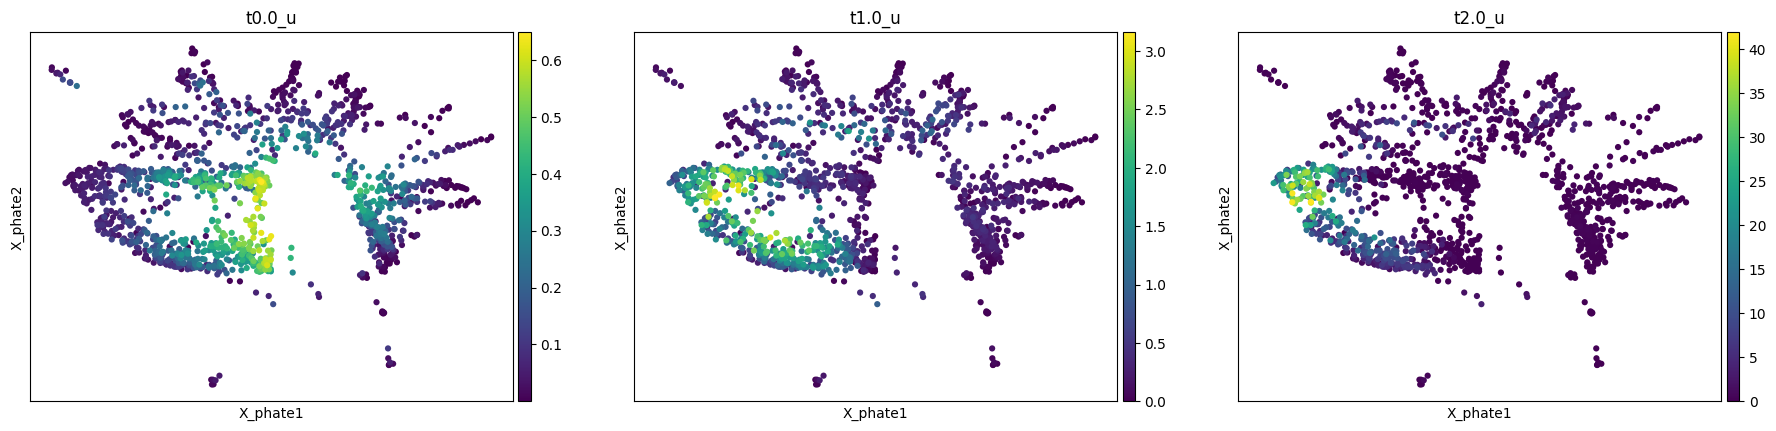

In [ ]:
sc.pp.neighbors(syn_ad, n_neighbors=30, use_rep='X_data')
sc.tl.umap(syn_ad)

phate_op = phate.PHATE(knn=5, random_state=2, gamma=-0.5);
syn_ad.obsm['X_phate'] = phate_op.fit_transform(syn_ad.X)
sc.pl.embedding(syn_ad, 'X_phate', color=['t0.0_u', 't1.0_u', 't2.0_u'])

In [ ]:
sc.pp.neighbors(syn_ad, n_neighbors=5, use_rep='X_data')
sc.tl.leiden(syn_ad, resolution=1)

In [ ]:
sc.tl.leiden(syn_ad, resolution=0.1, key_added='leiden_rs0.1')

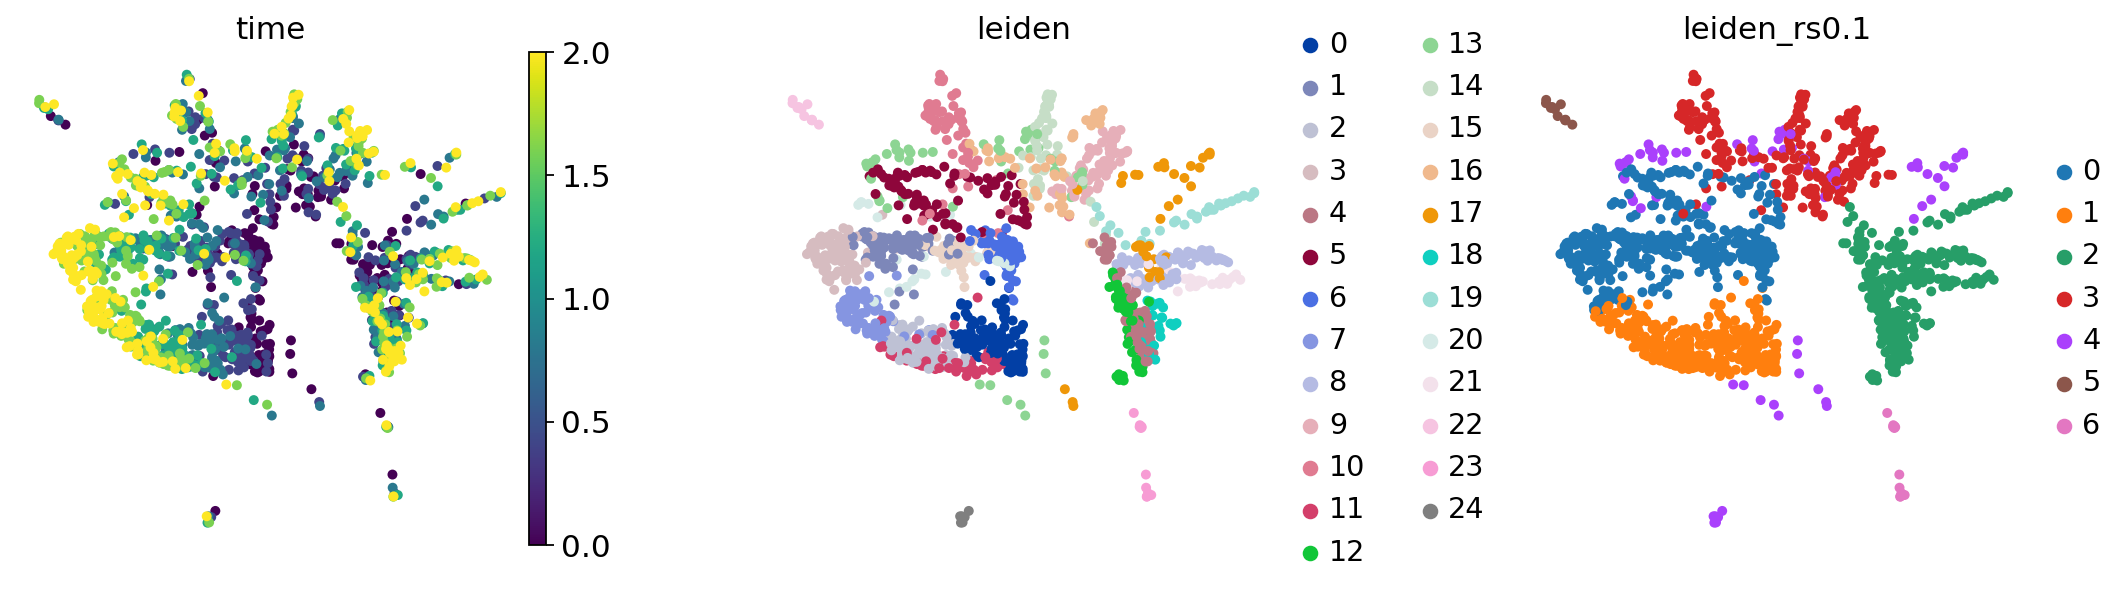

In [ ]:
sc.pl.embedding(syn_ad, 'X_phate', color=['time', 'leiden','leiden_rs0.1'], wspace=0.35)

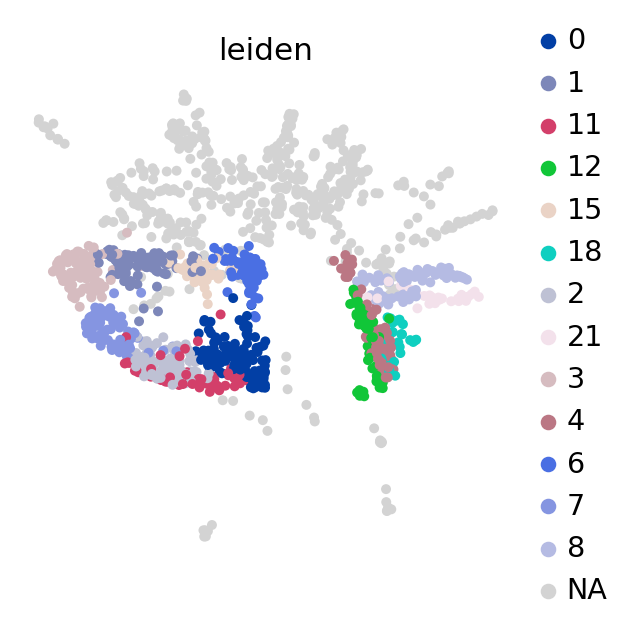

In [ ]:
lhs_cluster = ['0','1', '2', '3', '6', '7','11','15' ]
rhs_cluster = ['12','4','18','8','21']
cluster_of_interest = lhs_cluster + rhs_cluster

sc.pl.embedding(syn_ad, 'X_phate', color=['leiden'],
                 groups=cluster_of_interest)

# sc.pl.embedding(syn_ad, 'X_phate', color=['leiden'],
#                  groups=rhs_cluster)